In [1]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

In [2]:
base_dir = '../input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/'

train_pneumonia_dir = base_dir+'train/PNEUMONIA/'
train_normal_dir = base_dir+'train/NORMAL/'

test_pneumonia_dir = base_dir+'test/PNEUMONIA/'
test_normal_dir = base_dir+'test/NORMAL/'

val_pneumonia_dir = base_dir+'val/PNEUMONIA/'
val_normal_dir = base_dir+'val/NORMAL/'
train_pn = [train_pneumonia_dir+i for i in os.listdir(train_pneumonia_dir)]
train_normal = [train_normal_dir+i for i in os.listdir(train_normal_dir)]

test_pn = [test_pneumonia_dir+i for i in os.listdir(test_pneumonia_dir)]
test_normal = [test_normal_dir+i for i in os.listdir(test_normal_dir)]

val_pn = [val_pneumonia_dir+i for i in os.listdir(val_pneumonia_dir)]
val_normal = [val_normal_dir+i for i in os.listdir(val_normal_dir)]

pn = train_pn + test_pn + val_pn
normal = train_normal + test_normal + val_normal

In [3]:
train_imgs = pn[:3418] + normal[:1224]

test_imgs = pn[3418:4059] + normal[1224:1502]

random.shuffle(train_imgs)
random.shuffle(test_imgs)

In [4]:
IMG_SIZE = 128

def preprocess_image(img_path):

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    img = img / 255.0

    img = img.flatten()

    return img

In [5]:
def create_dataset(img_list):

    X = []
    y = []

    for img_path in tqdm(img_list):

        try:

            img = preprocess_image(img_path)

            X.append(img)

            if 'PNEUMONIA' in img_path:
                y.append(1)
            else:
                y.append(0)

        except:
            pass

    return np.array(X), np.array(y)

In [6]:
print("\nProcessing Training Data...")
X_train, y_train = create_dataset(train_imgs)

print("\nProcessing Testing Data...")
X_test, y_test = create_dataset(test_imgs)

print("\nOriginal Shape :", X_train.shape)


Processing Training Data...


100%|██████████| 4642/4642 [01:21<00:00, 56.97it/s]



Processing Testing Data...


100%|██████████| 919/919 [00:16<00:00, 54.55it/s]



Original Shape : (4642, 16384)


In [7]:
pca = PCA(n_components=150)

X_train_pca = pca.fit_transform(X_train)

X_test_pca = pca.transform(X_test)

print("\nAfter PCA Shape :", X_train_pca.shape)


After PCA Shape : (4642, 150)


In [8]:
xgb_model = XGBClassifier(

    n_estimators = 100,

    max_depth = 6,

    learning_rate = 0.1,

    objective = 'binary:logistic',

    eval_metric = 'logloss',

    random_state = 42
)


In [9]:
print("\nTraining PCA + XGBoost Model...\n")

xgb_model.fit(X_train_pca, y_train)
y_pred = xgb_model.predict(X_test_pca)


Training PCA + XGBoost Model...



In [10]:
accuracy = accuracy_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)

TN, FP, FN, TP = cm.ravel()

sensitivity = TP / (TP + FN)

specificity = TN / (TN + FP)

In [11]:
print("\n===================================================")
print("     CHEST X-RAY PCA + XGBOOST RESULTS")
print("===================================================\n")

print(f"Accuracy      : {accuracy*100:.2f}%")

print(f"F1-Score      : {f1:.4f}")

print(f"Sensitivity   : {sensitivity:.4f}")

print(f"Specificity   : {specificity:.4f}")

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")

print(cm)


     CHEST X-RAY PCA + XGBOOST RESULTS

Accuracy      : 87.05%
F1-Score      : 0.9135
Sensitivity   : 0.9797
Specificity   : 0.6187

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.62      0.74       278
           1       0.86      0.98      0.91       641

    accuracy                           0.87       919
   macro avg       0.89      0.80      0.83       919
weighted avg       0.88      0.87      0.86       919


Confusion Matrix:

[[172 106]
 [ 13 628]]


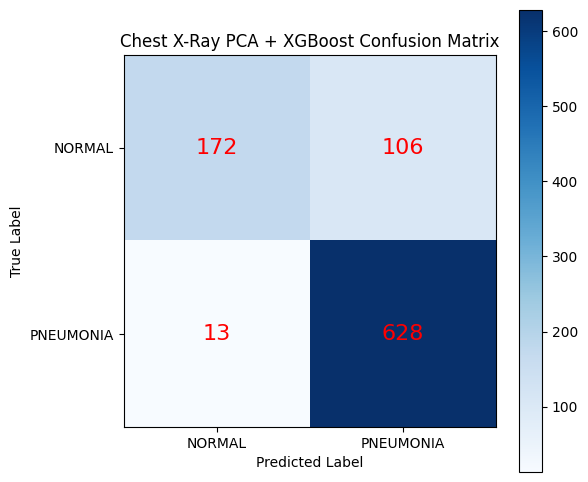

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.imshow(cm, cmap='Blues')

plt.title("Chest X-Ray PCA + XGBoost Confusion Matrix")

plt.xticks([0,1], ['NORMAL', 'PNEUMONIA'])

plt.yticks([0,1], ['NORMAL', 'PNEUMONIA'])

# Display values inside matrix
for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center',
            color='red',
            fontsize=16
        )

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.colorbar()

plt.show()